<div align="center">

**MSCS 634**

**Lab 4: Regression Analysis with Regularization Techniques**

**Peera Tienthong**

</div>

<h2>Step 1: Data Preparation</h2>

In [1]:
from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

# Optional quick check
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [4]:
# Data cleaning: check and handle missing values + duplicates
combined_data = X.copy()
combined_data['target'] = y

missing_before = combined_data.isnull().sum()
missing_total_before = int(missing_before.sum())

# fill missing values with median for numeric columns
if missing_total_before > 0:
    numeric_cols = combined_data.select_dtypes(include='number').columns
    combined_data[numeric_cols] = combined_data[numeric_cols].fillna(combined_data[numeric_cols].median())

# drop duplicate rows if any
duplicates_before = int(combined_data.duplicated().sum())
if duplicates_before > 0:
    combined_data = combined_data.drop_duplicates()

missing_after = combined_data.isnull().sum()
missing_total_after = int(missing_after.sum())

# Update X and y after cleaning
X = combined_data.drop(columns='target')
y = combined_data['target']

print(f'Missing values before cleaning: {missing_total_before}')
print(f'Missing values after cleaning: {missing_total_after}')
print(f'Duplicate rows removed: {duplicates_before}')
print(f'Final dataset shape: {combined_data.shape}')

Missing values before cleaning: 0
Missing values after cleaning: 0
Duplicate rows removed: 0
Final dataset shape: (442, 11)


In [5]:
import pandas as pd

# Feature distribution summary
feature_distribution = X.describe().T

# Target distribution summary
target_distribution = y.describe()

# Target frequency by bins
target_bins = pd.cut(y, bins=10)
target_bin_counts = target_bins.value_counts().sort_index()

feature_distribution

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [6]:
target_distribution, target_bin_counts

(count    442.000000
 mean     152.133484
 std       77.093005
 min       25.000000
 25%       87.000000
 50%      140.500000
 75%      211.500000
 max      346.000000
 Name: target, dtype: float64,
 target
 (24.679, 57.1]    38
 (57.1, 89.2]      80
 (89.2, 121.3]     68
 (121.3, 153.4]    62
 (153.4, 185.5]    50
 (185.5, 217.6]    41
 (217.6, 249.7]    38
 (249.7, 281.8]    42
 (281.8, 313.9]    17
 (313.9, 346.0]     6
 Name: count, dtype: int64)

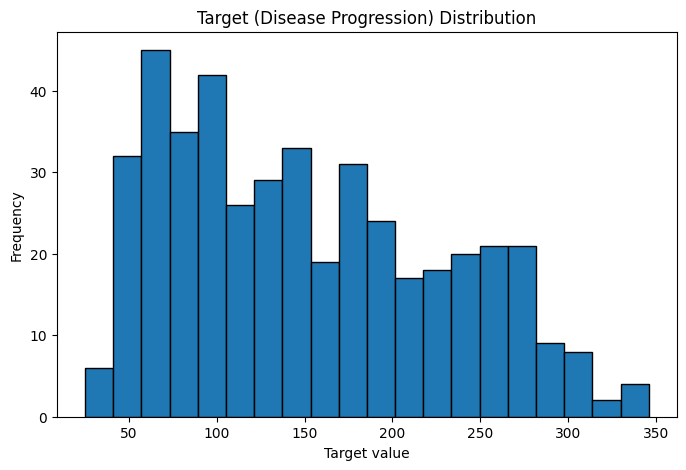

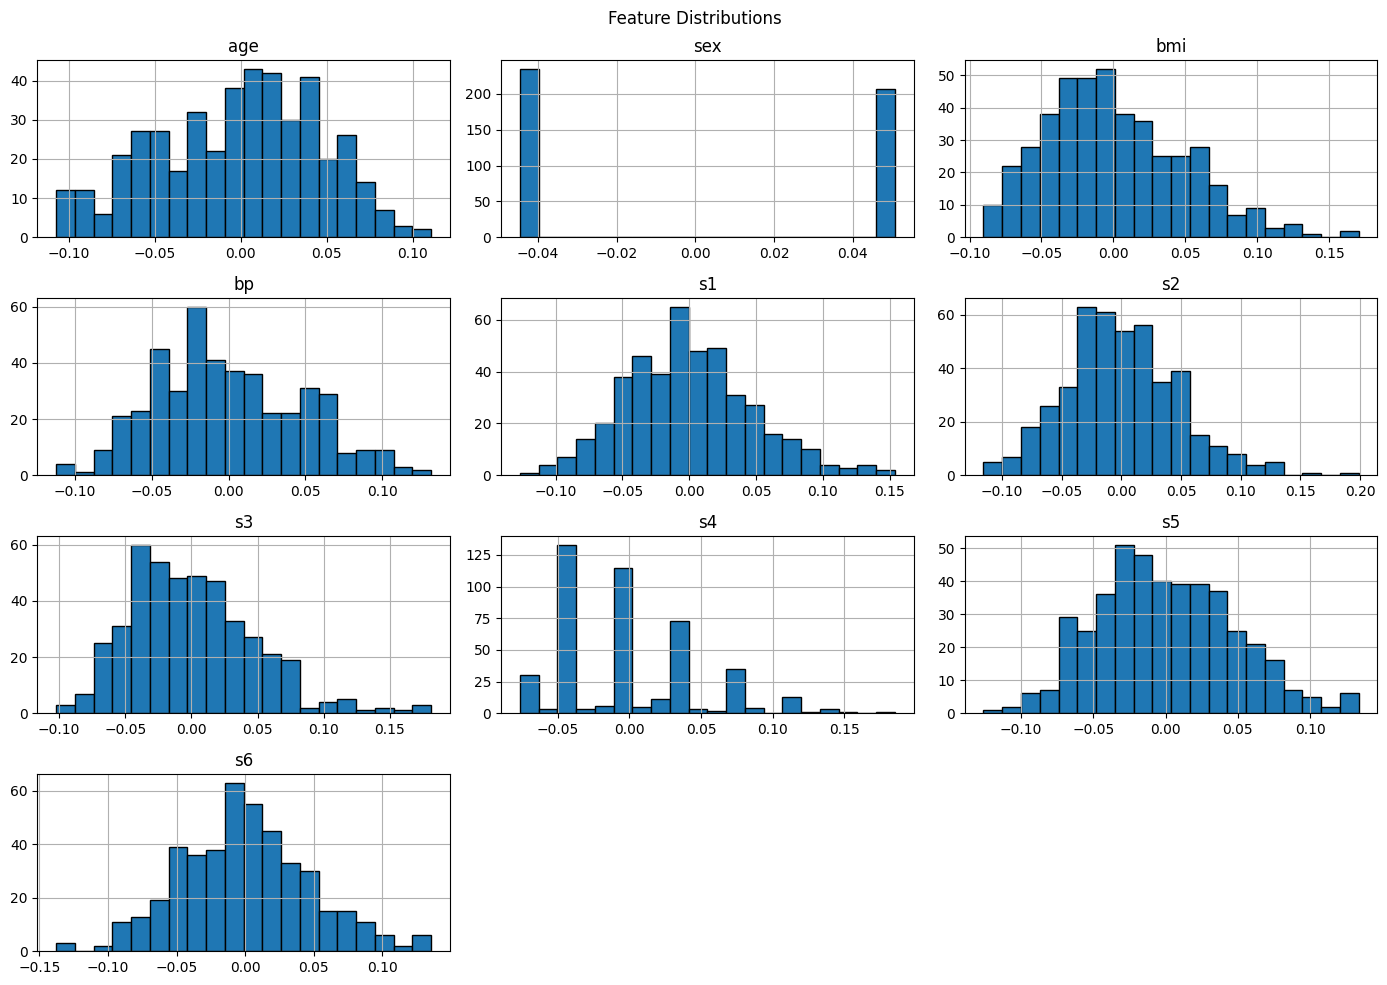

In [2]:
import matplotlib.pyplot as plt

# Target distribution histogram
plt.figure(figsize=(8, 5))
plt.hist(y, bins=20, edgecolor='black')
plt.title('Target (Disease Progression) Distribution')
plt.xlabel('Target value')
plt.ylabel('Frequency')
plt.show()

# Feature distributions histogram
X.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

<h2>Step 2: Linear Regression</h2>

In [5]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Simple Linear Regression using one feature: bmi
single_feature = 'bmi'
X_train_simple = X_train[[single_feature]]
X_test_simple = X_test[[single_feature]]

simple_lr_model = LinearRegression()
simple_lr_model.fit(X_train_simple, y_train)

y_pred_simple = simple_lr_model.predict(X_test_simple)

mse_simple = mean_squared_error(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = mse_simple ** 0.5
r2_simple = r2_score(y_test, y_pred_simple)

print(f'Feature used: {single_feature}')
print(f'Intercept: {simple_lr_model.intercept_:.4f}')
print(f'Coefficient ({single_feature}): {simple_lr_model.coef_[0]:.4f}')
print(f'MAE: {mae_simple:.4f}')
print(f'MSE: {mse_simple:.4f}')
print(f'RMSE: {rmse_simple:.4f}')
print(f'R^2 Score: {r2_simple:.4f}')

Feature used: bmi
Intercept: 152.0034
Coefficient (bmi): 998.5777
MAE: 52.2600
MSE: 4061.8259
RMSE: 63.7325
R^2 Score: 0.2334


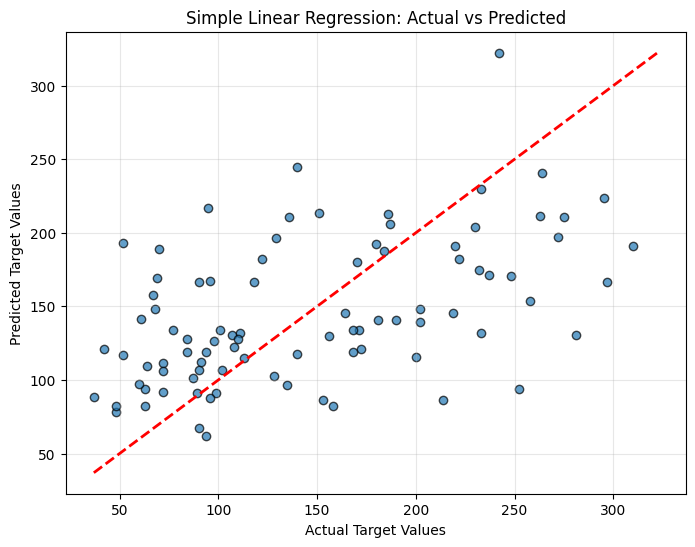

In [9]:
# Visualize predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_simple, alpha=0.7, edgecolor='k')

min_val = min(y_test.min(), y_pred_simple.min())
max_val = max(y_test.max(), y_pred_simple.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title('Simple Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.grid(True, alpha=0.3)
plt.show()

<h2>Step 3: Multiple Regression</h2>

In [10]:
# Multiple Regression using all features
multiple_lr_model = LinearRegression()
multiple_lr_model.fit(X_train, y_train)

y_pred_multiple = multiple_lr_model.predict(X_test)

mse_multiple = mean_squared_error(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = mse_multiple ** 0.5
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f'Number of features used: {X_train.shape[1]}')
print(f'Intercept: {multiple_lr_model.intercept_:.4f}')
print(f'MAE: {mae_multiple:.4f}')
print(f'MSE: {mse_multiple:.4f}')
print(f'RMSE: {rmse_multiple:.4f}')
print(f'R^2 Score: {r2_multiple:.4f}')

Number of features used: 10
Intercept: 151.3456
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R^2 Score: 0.4526


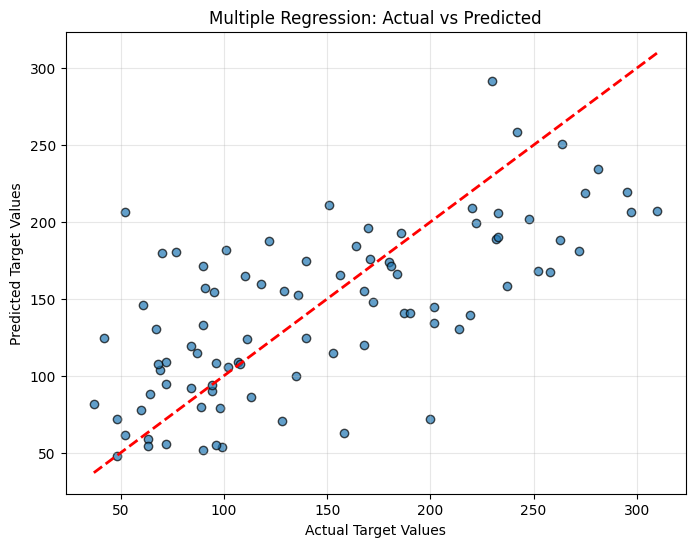

In [11]:
# Visualize predicted vs actual values for Multiple Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multiple, alpha=0.7, edgecolor='k')

min_val_multi = min(y_test.min(), y_pred_multiple.min())
max_val_multi = max(y_test.max(), y_pred_multiple.max())
plt.plot([min_val_multi, max_val_multi], [min_val_multi, max_val_multi], 'r--', linewidth=2)

plt.title('Multiple Regression: Actual vs Predicted')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.grid(True, alpha=0.3)
plt.show()

<h2>Step 4: Polynomial Regression</h2>

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Regression (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_lr_model = LinearRegression()
poly_lr_model.fit(X_train_poly, y_train)

y_pred_poly = poly_lr_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = mse_poly ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print('Polynomial degree: 2')
print(f'Original feature count: {X_train.shape[1]}')
print(f'Expanded feature count: {X_train_poly.shape[1]}')
print(f'MAE: {mae_poly:.4f}')
print(f'MSE: {mse_poly:.4f}')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2 Score: {r2_poly:.4f}')

Polynomial degree: 2
Original feature count: 10
Expanded feature count: 65
MAE: 43.5817
MSE: 3096.0283
RMSE: 55.6420
R^2 Score: 0.4156


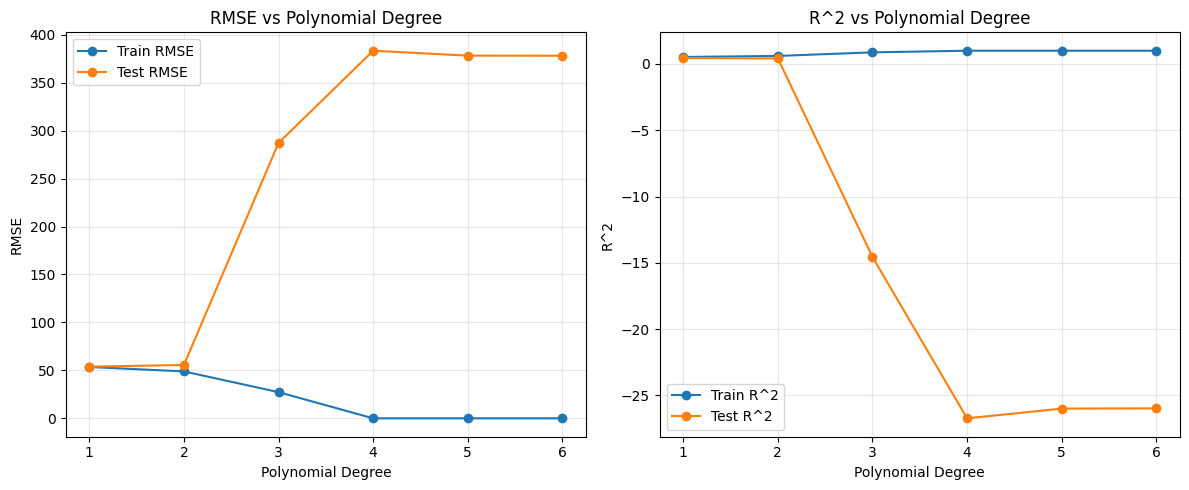

Best degree by test R^2: 1


In [14]:
import pandas as pd
# Effect of polynomial degree on underfitting vs overfitting
degrees = range(1, 7)
results = []

for degree in degrees:
    poly_degree = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_deg = poly_degree.fit_transform(X_train)
    X_test_deg = poly_degree.transform(X_test)

    model_deg = LinearRegression()
    model_deg.fit(X_train_deg, y_train)

    y_train_pred_deg = model_deg.predict(X_train_deg)
    y_test_pred_deg = model_deg.predict(X_test_deg)

    train_rmse = mean_squared_error(y_train, y_train_pred_deg) ** 0.5
    test_rmse = mean_squared_error(y_test, y_test_pred_deg) ** 0.5
    train_r2 = r2_score(y_train, y_train_pred_deg)
    test_r2 = r2_score(y_test, y_test_pred_deg)

    results.append({
        'degree': degree,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
    })

degree_results = pd.DataFrame(results)
degree_results

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degree_results['degree'], degree_results['train_rmse'], marker='o', label='Train RMSE')
plt.plot(degree_results['degree'], degree_results['test_rmse'], marker='o', label='Test RMSE')
plt.title('RMSE vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(degree_results['degree'], degree_results['train_r2'], marker='o', label='Train R^2')
plt.plot(degree_results['degree'], degree_results['test_r2'], marker='o', label='Test R^2')
plt.title('R^2 vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R^2')
plt.xticks(list(degrees))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_degree = degree_results.loc[degree_results['test_r2'].idxmax(), 'degree']
print(f'Best degree by test R^2: {int(best_degree)}')

the model is clearly overfitting at higher polynomial degrees.

- Degree 1–2: train and test curves are close, and test 
R^2 is positive (~0.5), so generalization is reasonable (little/no overfitting).
- Degree 3+: train RMSE drops a lot while test RMSE explodes, and test 
R^2 becomes very negative. This is classic severe overfitting.
- At degrees 4–6, train RMSE is near 0 but test performance is very poor, meaning the model is memorizing training data instead of learning general patterns.


<h2>Step 5: Regularization with Ridge and Lasso Regression</h2> 

- `alpha` controls how strongly coefficients are penalized.
- Small `alpha` (close to 0) keeps the model similar to ordinary linear regression, with lower bias but higher overfitting risk.
- Large `alpha` shrinks coefficients more, reducing variance and overfitting risk, but can increase bias and cause underfitting.

**Ridge (`L2`)**
- Shrinks all coefficients smoothly toward zero.
- Usually keeps all features in the model.

**Lasso (`L1`)**
- Can shrink some coefficients exactly to zero.
- Performs implicit feature selection.

In this notebook, Lasso (`alpha=0.1`) produced better test metrics than Ridge (`alpha=1.0`), suggesting that this `alpha` choice gave a better bias-variance balance for the dataset.

In [15]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso Regression
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso ** 0.5
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Ridge Regression Results')
print(f'MAE: {mae_ridge:.4f}')
print(f'MSE: {mse_ridge:.4f}')
print(f'RMSE: {rmse_ridge:.4f}')
print(f'R^2 Score: {r2_ridge:.4f}')
print()
print('Lasso Regression Results')
print(f'MAE: {mae_lasso:.4f}')
print(f'MSE: {mse_lasso:.4f}')
print(f'RMSE: {rmse_lasso:.4f}')
print(f'R^2 Score: {r2_lasso:.4f}')

Ridge Regression Results
MAE: 46.1389
MSE: 3077.4159
RMSE: 55.4745
R^2 Score: 0.4192

Lasso Regression Results
MAE: 42.8544
MSE: 2798.1935
RMSE: 52.8980
R^2 Score: 0.4719


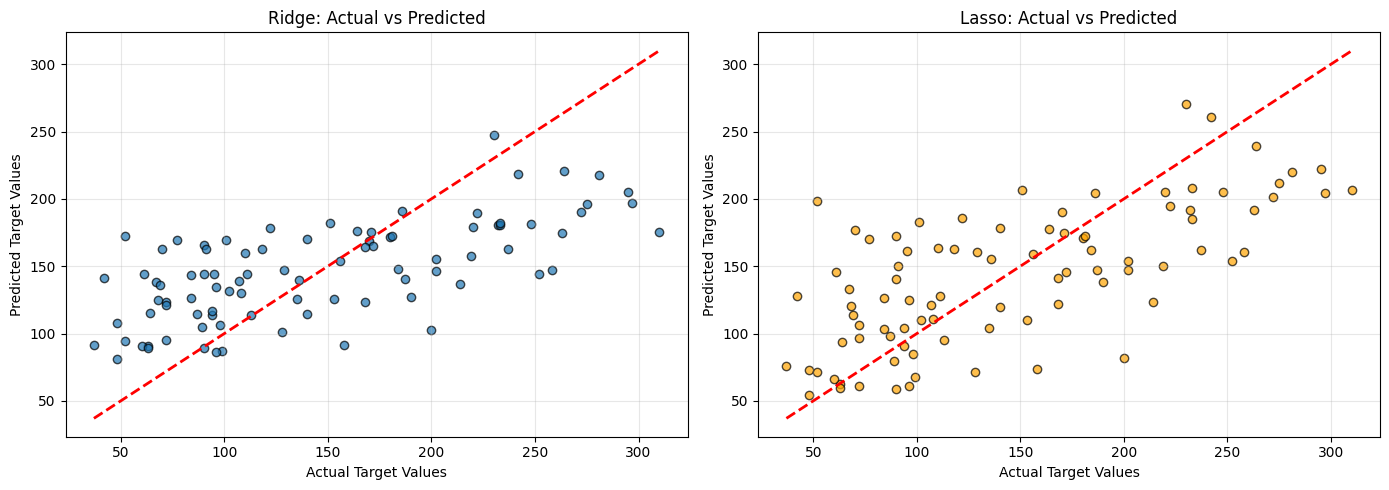

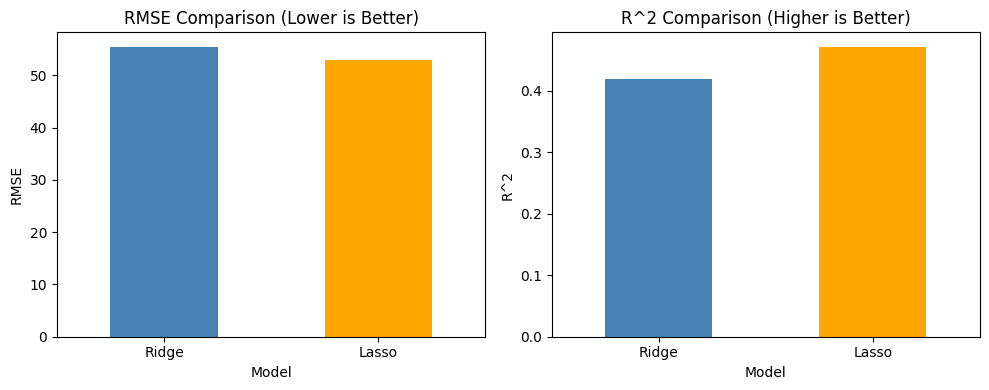

Better test performance based on R^2: Lasso


In [16]:
# Visualize Ridge vs Lasso predictions and compare performance
plt.figure(figsize=(14, 5))

# Ridge: actual vs predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_ridge, alpha=0.7, edgecolor='k', label='Ridge')
min_val_reg = min(y_test.min(), y_pred_ridge.min(), y_pred_lasso.min())
max_val_reg = max(y_test.max(), y_pred_ridge.max(), y_pred_lasso.max())
plt.plot([min_val_reg, max_val_reg], [min_val_reg, max_val_reg], 'r--', linewidth=2)
plt.title('Ridge: Actual vs Predicted')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.grid(True, alpha=0.3)

# Lasso: actual vs predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_lasso, alpha=0.7, edgecolor='k', color='orange', label='Lasso')
plt.plot([min_val_reg, max_val_reg], [min_val_reg, max_val_reg], 'r--', linewidth=2)
plt.title('Lasso: Actual vs Predicted')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Metric comparison chart
comparison_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'RMSE': [rmse_ridge, rmse_lasso],
    'R^2': [r2_ridge, r2_lasso],
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comparison_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[0], color=['steelblue', 'orange'], legend=False)
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=0)

comparison_df.plot(x='Model', y='R^2', kind='bar', ax=axes[1], color=['steelblue', 'orange'], legend=False)
axes[1].set_title('R^2 Comparison (Higher is Better)')
axes[1].set_ylabel('R^2')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

better_model = 'Lasso' if r2_lasso > r2_ridge else 'Ridge'
print(f'Better test performance based on R^2: {better_model}')

<h2>Step 6: Model Comparison and Analysis</h2>

In [17]:
# Step 6: Model comparison summary
model_comparison = pd.DataFrame([
    {
        'Model': 'Simple Linear (bmi)',
        'MAE': mae_simple,
        'MSE': mse_simple,
        'RMSE': rmse_simple,
        'R^2': r2_simple,
    },
    {
        'Model': 'Multiple Linear',
        'MAE': mae_multiple,
        'MSE': mse_multiple,
        'RMSE': rmse_multiple,
        'R^2': r2_multiple,
    },
    {
        'Model': 'Polynomial (degree=2)',
        'MAE': mae_poly,
        'MSE': mse_poly,
        'RMSE': rmse_poly,
        'R^2': r2_poly,
    },
    {
        'Model': 'Ridge',
        'MAE': mae_ridge,
        'MSE': mse_ridge,
        'RMSE': rmse_ridge,
        'R^2': r2_ridge,
    },
    {
        'Model': 'Lasso',
        'MAE': mae_lasso,
        'MSE': mse_lasso,
        'RMSE': rmse_lasso,
        'R^2': r2_lasso,
    },
])

model_comparison = model_comparison.sort_values(by='R^2', ascending=False).reset_index(drop=True)
model_comparison_rounded = model_comparison.copy()
model_comparison_rounded[['MAE', 'MSE', 'RMSE', 'R^2']] = model_comparison_rounded[['MAE', 'MSE', 'RMSE', 'R^2']].round(4)

best_r2_model = model_comparison.iloc[0]['Model']
best_rmse_model = model_comparison.loc[model_comparison['RMSE'].idxmin(), 'Model']

print(f'Best model by R^2: {best_r2_model}')
print(f'Best model by RMSE: {best_rmse_model}')
model_comparison_rounded

Best model by R^2: Lasso
Best model by RMSE: Lasso


,Model,MAE,MSE,RMSE,R^2
0,Lasso,42.8544,2798.1935,52.8980,0.4719
1,Multiple Linear,42.7941,2900.1936,53.8534,0.4526
2,Ridge,46.1389,3077.4159,55.4745,0.4192
3,Polynomial (degree=2),43.5817,3096.0283,55.6420,0.4156
4,Simple Linear (bmi),52.2600,4061.8259,63.7325,0.2334


### How Well Each Model Performed?

Based on the test-set metrics in Step 6:

1. **Lasso** performed best overall (`R^2 = 0.4719`, `RMSE = 52.8980`). It achieved the strongest generalization, likely by shrinking less useful coefficients.
2. **Multiple Linear Regression** was a close second (`R^2 = 0.4526`, `RMSE = 53.8534`), showing that using all original features improves performance over the single-feature model.
3. **Ridge Regression** performed moderately well (`R^2 = 0.4192`, `RMSE = 55.4745`), but slightly below Multiple Linear and Lasso for this dataset.
4. **Polynomial Regression (degree=2)** did not improve performance here (`R^2 = 0.4156`, `RMSE = 55.6420`), suggesting added polynomial terms were not beneficial for test generalization.
5. **Simple Linear Regression (bmi only)** performed worst (`R^2 = 0.2334`, `RMSE = 63.7325`), indicating one feature alone is insufficient to model target variability.

**Overall conclusion:** Regularized and multi-feature models clearly outperform the simple one-feature baseline, with **Lasso** providing the best balance of prediction accuracy and generalization on this test split.    

### Overfitting Control and Performance Improvement

- **Best overfitting control:** **Lasso** handled overfitting most effectively in this lab. Its regularization reduced model complexity and produced the best test performance (`R^2 = 0.4719`, lowest `RMSE = 52.8980`).
- **Strong baseline improvement:** **Multiple Linear Regression** improved substantially over the simple one-feature model by using all predictors (`R^2 = 0.4526` vs `0.2334`).
- **Ridge performance:** **Ridge** also reduced overfitting risk through coefficient shrinkage and gave stable results (`R^2 = 0.4192`), but it was slightly less accurate than Lasso on this dataset.
- **Polynomial behavior:** The degree-2 polynomial model did not improve test performance here (`R^2 = 0.4156`), and higher-degree experiments showed clear overfitting (very low train error but much worse test metrics).
- **Most underpowered model:** **Simple Linear (bmi only)** underfit relative to the others, since one feature could not capture enough target variability.

**Conclusion:** Models with regularization—especially **Lasso**—provided the best balance between controlling overfitting and improving predictive accuracy.

### Insights Gained About the Diabetes Dataset

- The target variable shows substantial spread, indicating meaningful variability in disease progression that is not explained by a single predictor.
- Using all available clinical features clearly improves prediction compared with using only `bmi`, suggesting diabetes progression is influenced by multiple interacting factors.
- The feature set appears mostly linear to moderately nonlinear for this split: linear and regularized linear models perform well, while higher-degree polynomial models overfit quickly.
- Regularization is useful for this dataset: Lasso achieved the best generalization performance, indicating that shrinking/zeroing weaker coefficients helps reduce noise effects.
- Overall, the dataset contains predictive signal but also enough complexity/noise that model simplicity plus regularization provides better test performance than more complex polynomial expansion.